# Step1 : Bussiness Problem Understanding

- What is the relationship between each advertising channel(Tv,radio,newspaper) and sales.

# Step2 : Data Understanding

- Data: The sample data sales for a perticular function of adevertising budget (in dollers) for TV,Radio,Newspaper media
- Independent variables(TV,Radio,Newspaper),Target variable(Sales)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         200 non-null    int64
 1   radio      200 non-null    int64
 2   newspaper  200 non-null    int64
 3   sales      200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [17]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147042.500000,23264.000000,30554.000000,14022.500000
std,85854.236315,14846.809176,21778.620839,5217.456566
min,700.000000,0.000000,300.000000,1600.000000
25%,74375.000000,9975.000000,12750.000000,10375.000000
50%,149750.000000,22900.000000,25750.000000,12900.000000
75%,218825.000000,36525.000000,45100.000000,17400.000000
max,296400.000000,49600.000000,114000.000000,27000.000000


# Step3: NO data cleaning required
# Step4: NO data wrangling required

In [20]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


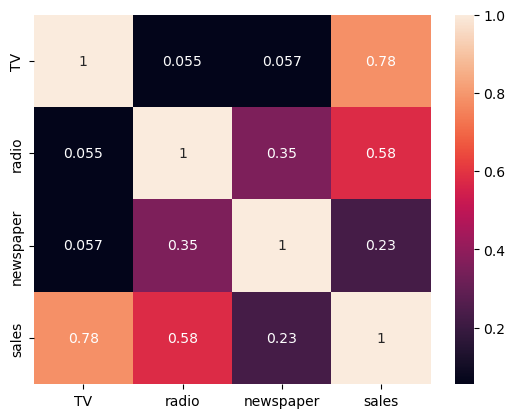

In [22]:
sns.heatmap(df.corr(),annot=True)
plt.show()

- The relation between output and input variable should be high.
- The higher the value the stronger the rlation.
- If it has less corelation,it is problem......less accuracy.
- if any input variable has less than 0.2 coreation with output variable,then that input variable should be dropped.
- The ralation between two independent variables should be low.
- If the corealation between two independent varible >=0.05 then it is called colonarity problem.
- **solution:** 1 out of 2.

**X and y**

In [26]:
X=df.drop(columns=['sales'])
y=df['sales']

In [28]:
X

,TV,radio,newspaper
0,230100,37800,69200
1,44500,39300,45100
2,17200,45900,69300
3,151500,41300,58500
4,180800,10800,58400
...,...,...,...
195,38200,3700,13800
196,94200,4900,8100
197,177000,9300,6400
198,283600,42000,66200


**Train-Test split**

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

# Step5: **Modeling**
* 3 input variables

In [34]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [36]:
print("Inttercept",model.intercept_)
print("coeficent",model.coef_)

Inttercept 3254.0971144188843
coeficent [ 0.0437726   0.19343299 -0.00222879]


# Step6: Evaluation

In [38]:
#prediction on train data
ypred_train=model.predict(X_train)
#Evaluation on train data
from sklearn.metrics import r2_score
print("Train r2 score:",r2_score(y_train,ypred_train))

Train r2 score: 0.9209087553499528


In [39]:
from sklearn.model_selection import cross_val_score
print("cross_validation_score:",cross_val_score(model,X_train,y_train,cv=5).mean())

cross_validation_score: 0.9157327701186169


In [40]:
#prediction on train data
ypred_test=model.predict(X_test)
#Evaluation on test data
from sklearn.metrics import r2_score
print("Test r2 score:",r2_score(y_test,ypred_test))

Test r2 score: 0.8353672324670594


# Step6: Model selection

- Condition1: Train==cv(satisfied).
- Condition2: Train==Test(not satisfied).
- Condition3: Business problem(not satisfied).
- ONLY for LINEAR REGRESSION --->Assumptions must be satisfied

**Check for assumptions**

- Linearity of Error

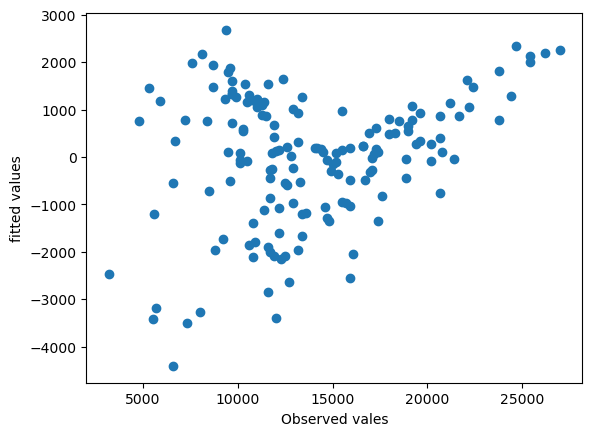

In [48]:
train_error=y_train-ypred_train
plt.scatter(y_train,train_error)
plt.xlabel("Observed vales")
plt.ylabel("fitted values")
plt.show()

- Normality of errors

In [50]:
train_error.skew()

-0.7040467730469484

- Equal variance of errors(Homoscadecity)

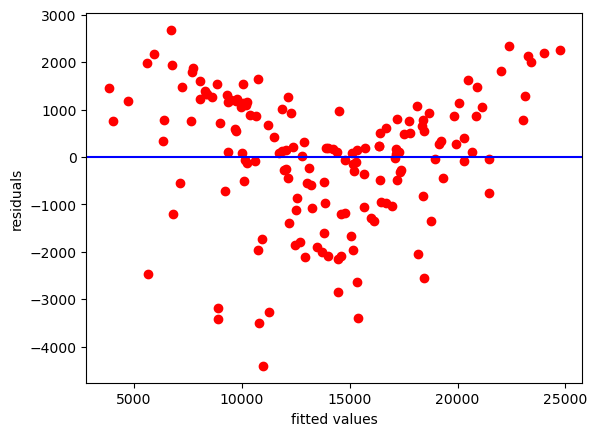

In [53]:
plt.scatter(ypred_train,train_error,c='r')
plt.axhline(y=0,color='blue')
plt.xlabel('fitted values')
plt.ylabel('residuals')
plt.show()

- Independent of Errors(significance of variable)

    Hypothesis tesing for variables
    - H0:There is no realation between input variable and ouput variable(bita1=0)
    - H1:There is realation between input variable and ouput variable(bita1!=0)

In [65]:
from sklearn.model_selection import train_test_split
df_train,df_test=train_test_split(df,test_size=0.2,random_state=10)

In [67]:
import statsmodels.formula.api as smf
model1=smf.ols('y_train~X_train',data=df_train).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                y_train   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     605.5
Date:                Tue, 24 Jun 2025   Prob (F-statistic):           1.09e-85
Time:                        22:30:10   Log-Likelihood:                -1381.9
No. Observations:                 160   AIC:                             2772.
Df Residuals:                     156   BIC:                             2784.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3254.0971    286.349     11.364      0.000    2688.475    3819.719
X_train[0]     0.0438      0.001     32.429      0.000       0.041       0.046
X_train[1]     0.1934      0.008     24.310      0.000       0.178       0.209
X_train[2]    -0.0022      0.005     -0.415      0.679      -0.013       0.008
==============================================================================
Omnibus:                       12.534   Durbin-Watson:                   2.105
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               13.333
Skew:                          -0.697   Prob(JB):                      0.00127
Kurtosis:                       3.233   Cond. No.                     4.46e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.46e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- Added variable plot(AV plot)
  - Partial diffrentation insted of normal diffrentation

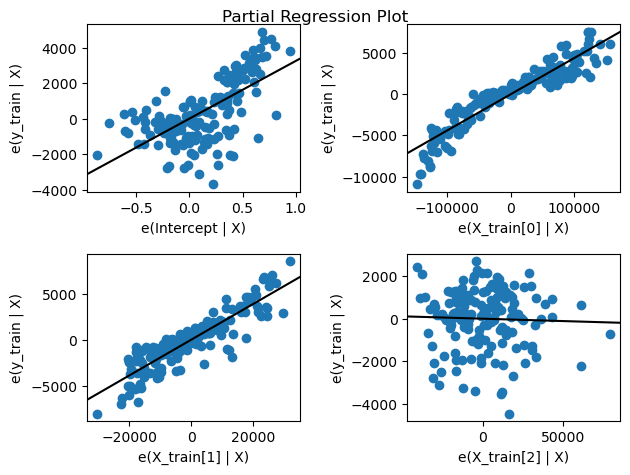

In [81]:
import statsmodels.api as sm
sm.graphics.plot_partregress_grid(model1)
plt.show()

- news paper has nocorelation
- news papeer no AV plot
- news paper no summary

# Let try by dropping influential records

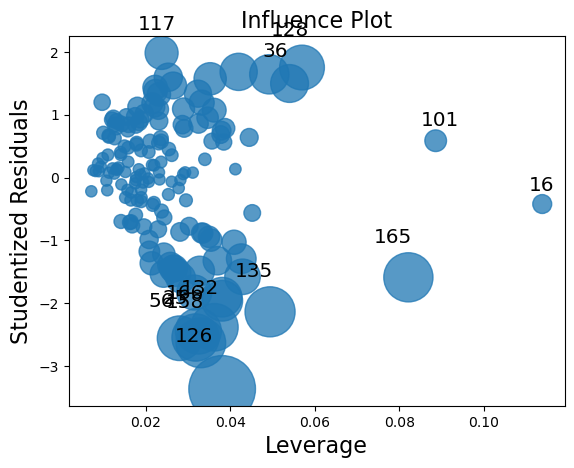

In [85]:
import statsmodels.api as sm
sm.graphics.influence_plot(model1)
plt.show()

In [87]:
#drop the influential records
df.drop(index=[165,101,16],inplace=True)
X=df.drop(columns=['sales'])
y=df['sales']

In [93]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [105]:
from sklearn.linear_model import LinearRegression
model2=LinearRegression()
model2.fit(X_train,y_train)
print("Intercept:",model2.intercept_)
print("Coeficent:",model2.coef_)

Intercept: 3024.8963654466716
Coeficent: [0.04414055 0.1949089  0.00427462]


In [115]:
ypred_train=model2.predict(X_train)
from sklearn.metrics import r2_score
print("Train r2score:",r2_score(y_train,ypred_train))
print("cross validation:",cross_val_score(model2,X_train,y_train,cv=5).mean())

Train r2score: 0.925237670029726
cross validation: 0.9105174163265672


In [117]:
ypred_test=model2.predict(X_test)
from sklearn.metrics import r2_score
print("Train r2score:",r2_score(y_test,ypred_test))

Train r2score: 0.7805578248006212


- Condition1: Train==cv(satisfied).
- Condition2: Train==Test(not satisfied).
- Condition3: Business problem(satisfied).

In [121]:
from sklearn.model_selection import train_test_split
df_train,df_test=train_test_split(df,test_size=0.2,random_state=10)

In [123]:
import statsmodels.formula.api as smf
model2=smf.ols('y_train~X_train',data=df_train).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                y_train   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     631.2
Date:                Tue, 24 Jun 2025   Prob (F-statistic):           6.55e-86
Time:                        23:18:08   Log-Likelihood:                -1359.3
No. Observations:                 157   AIC:                             2727.
Df Residuals:                     153   BIC:                             2739.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3024.8964    296.309     10.209      0.000    2439.511    3610.281
X_train[0]     0.0441      0.001     32.215      0.000       0.041       0.047
X_train[1]     0.1949      0.008     23.135      0.000       0.178       0.212
X_train[2]     0.0043      0.006      0.716      0.475      -0.008       0.016
==============================================================================
Omnibus:                       15.025   Durbin-Watson:                   2.266
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               16.512
Skew:                          -0.778   Prob(JB):                     0.000260
Kurtosis:                       3.316   Cond. No.                     4.57e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.57e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Final Model including TV and Radio

In [130]:
X=df.drop(columns=['sales','newspaper'])
y=df['sales']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)
from sklearn.linear_model import LinearRegression
model3=LinearRegression()
model3.fit(X_train,y_train)
print("Intercept:",model3.intercept_)
print("Coeficent:",model3.coef_)

Intercept: 3092.3977505023067
Coeficent: [0.04418711 0.19712401]


In [138]:
ypred_train=model3.predict(X_train)
from sklearn.metrics import r2_score
print("Train r2score:",r2_score(y_train,ypred_train))
from sklearn.model_selection import cross_val_score
print("cross validation:",cross_val_score(model3,X_train,y_train,cv=5).mean())

Train r2score: 0.9249869448846356
cross validation: 0.9106738268530424


In [140]:
ypred_test=model3.predict(X_test)
from sklearn.metrics import r2_score
print("Test r2score:",r2_score(y_test,ypred_test))

Test r2score: 0.782071332256224


- Condition1: Train==cv(satisfied).
- Condition2: Train==Test(not satisfied).
- Condition3: Business problem(satisfied).

- Try influential records
- Drop unimportant column
- still Overfitting problem
- **Conclusion: Linear Regression is not good for given data**